In [75]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [76]:
results_paths: dict = {
    "ablation_dense": {
        "no_entropy": "../data/exp1_ablation_dense_no_entropy.csv",
        "entropy": "../data/exp1_ablation_dense_entropy.csv"
    },
    "ablation_sparse": {
        "no_entropy": "../data/exp1_ablation_sparse_no_entropy.csv",
        "entropy": "../data/exp1_ablation_sparse_entropy.csv"
    },
    "toysim": {
        "no_entropy": "../data/exp1_toymap_no_entropy.csv",
        "entropy": "../data/exp1_toymap_entropy.csv"
    }
}

In [77]:
# Validate that all paths are correct
for dataset, values in results_paths.items():
    for entropy, path in values.items():
        try:
            pd.read_csv(path)
        except FileNotFoundError:
            print(f"File not found: {path}")
            exit(1)

In [78]:
# load all data
data_frames = {}
for dataset, values in results_paths.items():
    data_frames[dataset] = {}
    for entropy, path in values.items():
        df = pd.read_csv(path)
        
        # remove all columns with only one unique value
        df_filtered = df.loc[:, df.nunique() > 1]
        
        data_frames[dataset][entropy] = df_filtered

print(f"Data Keys: {data_frames.keys()}")
print(f"Data Values: {data_frames[list(data_frames.keys())[0]].keys()}")

Data Keys: dict_keys(['ablation_dense', 'ablation_sparse', 'toysim'])
Data Values: dict_keys(['no_entropy', 'entropy'])


In [79]:
print(data_frames["ablation_dense"]["no_entropy"].head())

   Unnamed: 0  test_nll  test_auc          decoding_method  axis_resolution  \
0           0  0.484939  0.939412                     relu              0.1   
1           1  0.504697  0.903999           relu_normalize              0.1   
2           2  0.617697  0.937240            relu_squaring              0.1   
3           3  0.562121  0.936633  relu_normalize_squaring              0.1   
4           4  0.494273  0.916347                     tanh              0.1   

   vector_length_scale  vector_dimensionality  
0                  0.1                  32768  
1                  0.1                  32768  
2                  0.1                  32768  
3                  0.1                  32768  
4                  0.1                  32768  


---
### Plot the distribution of the AUC and NLL across each dataset
---

In [80]:
# Load data into a structured format
box_plot_data = []
for dataset, entropy_config in data_frames.items():
    for entropy, df in entropy_config.items():
        for _, row in df.iterrows():
            box_plot_data.append({
                "Dataset": dataset,
                "Entropy": entropy,
                "Dataset_Entropy": f"{dataset}",
                "NLL": row["test_nll"],
                "AUC": row["test_auc"]
            })
box_plot_dataframe = pd.DataFrame(box_plot_data)
print(box_plot_dataframe.columns)
box_plot_dataframe.head()

Index(['Dataset', 'Entropy', 'Dataset_Entropy', 'NLL', 'AUC'], dtype='object')


,Dataset,Entropy,Dataset_Entropy,NLL,AUC
0,ablation_dense,no_entropy,ablation_dense,0.484939,0.939412
1,ablation_dense,no_entropy,ablation_dense,0.504697,0.903999
2,ablation_dense,no_entropy,ablation_dense,0.617697,0.937240
3,ablation_dense,no_entropy,ablation_dense,0.562121,0.936633
4,ablation_dense,no_entropy,ablation_dense,0.494273,0.916347


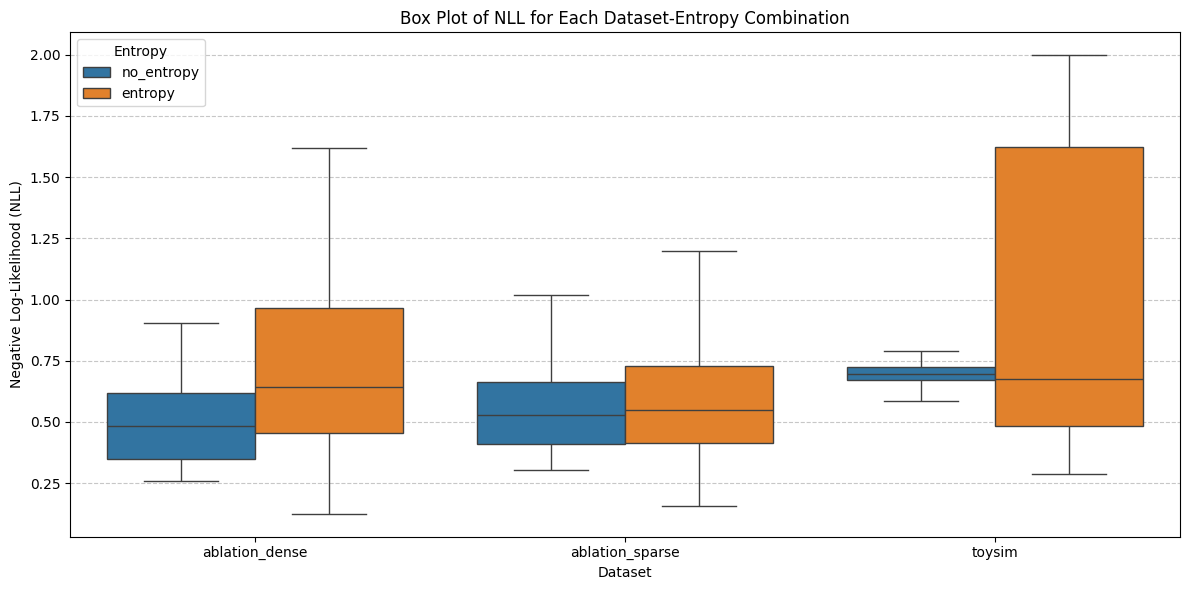

In [81]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Dataset_Entropy', y="NLL", data=box_plot_dataframe, hue="Entropy", showfliers=False, dodge=True)

# Improve readability
# plt.xticks(rotation=45, ha="right")
plt.xlabel("Dataset")
plt.ylabel("Negative Log-Likelihood (NLL)")
plt.title("Box Plot of NLL for Each Dataset-Entropy Combination")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.savefig("exp1_nll_boxplot.svg")
plt.show()

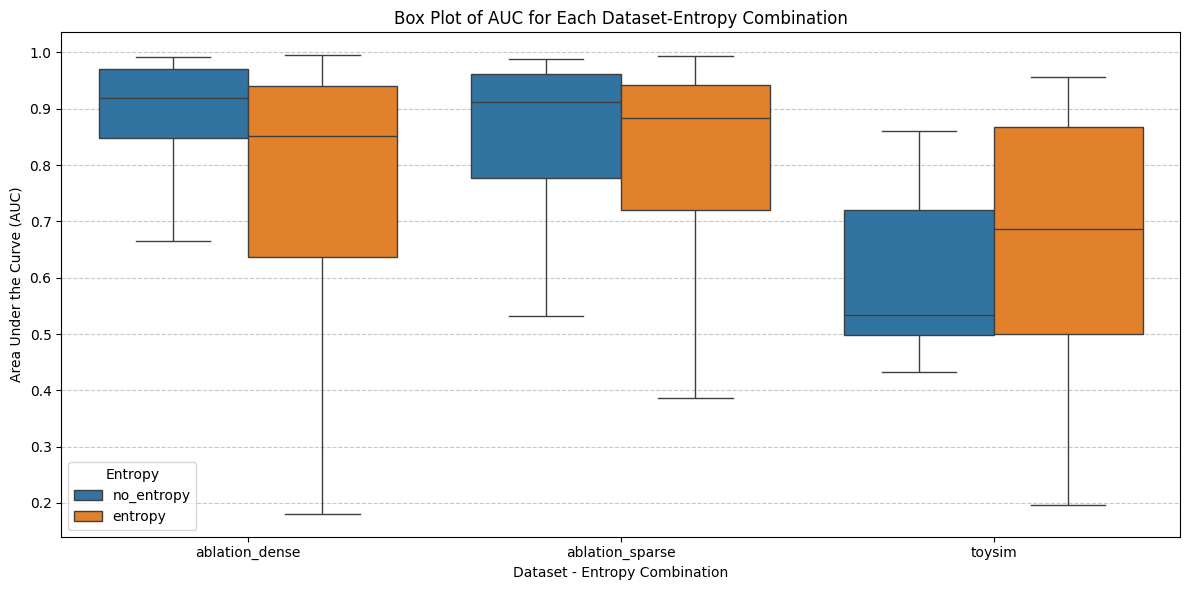

In [82]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Dataset_Entropy', y="AUC", data=box_plot_dataframe, hue="Entropy", showfliers=False, dodge=True)

# Improve readability
# plt.xticks(ha="right")
plt.xlabel("Dataset - Entropy Combination")
plt.ylabel("Area Under the Curve (AUC)")
plt.title("Box Plot of AUC for Each Dataset-Entropy Combination")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.savefig("exp1_auc_boxplot.svg")
plt.show()

---
### Pairplots for the parameters across each dataset based on NLL and AUC
---